## Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [57]:
import sklearn

## Load Dataset

In [58]:
df = pd.read_csv('ObesityDataSet.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (2111, 17)


In [59]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## Informasi Dataset

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [61]:
# Pisahkan kolom numerik dan kategorik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Kolom numerik ({len(numeric_cols)}): {numeric_cols}")
print(f"Kolom kategorik ({len(categorical_cols)}): {categorical_cols}")

Kolom numerik (8): ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Kolom kategorik (9): ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


## Cek Missing Values

In [62]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

## Feature Engineering - BMI

In [63]:
# Hitung BMI (Body Mass Index) = Weight / (Height^2)
df['BMI'] = df['Weight'] / (df['Height'] ** 2)

# Hapus kolom Height dan Weight
df = df.drop(['Height', 'Weight'], axis=1)

print(f"Dataset shape setelah feature engineering: {df.shape}")
print(f"Statistik BMI:")
print(df['BMI'].describe())

Dataset shape setelah feature engineering: (2111, 16)
Statistik BMI:
count    2111.000000
mean       29.700159
std         8.011337
min        12.998685
25%        24.325802
50%        28.719089
75%        36.016501
max        50.811753
Name: BMI, dtype: float64
count    2111.000000
mean       29.700159
std         8.011337
min        12.998685
25%        24.325802
50%        28.719089
75%        36.016501
max        50.811753
Name: BMI, dtype: float64


## Data Cleaning

In [65]:
# Cek duplikat
duplicates = df.duplicated().sum()
print(f"Jumlah data duplikat: {duplicates}")

if duplicates > 0:
    df_clean = df.drop_duplicates()
    print(f"Data setelah hapus duplikat: {df_clean.shape}")
else:
    df_clean = df.copy()

Jumlah data duplikat: 24
Data setelah hapus duplikat: (2087, 16)


### Deteksi Outlier

In [66]:
# Deteksi outlier pakai IQR
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers")

Age: 167 outliers
NCP: 577 outliers


## Exploratory Data Analysis

### Statistik Deskriptif

In [67]:
df_clean.describe()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,2.421466,2.701179,2.004749,1.012812,0.663035,29.765758
std,6.368801,0.534737,0.764614,0.608284,0.853475,0.608153,8.024934
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000,12.998685
25%,19.915937,2.000000,2.697467,1.590922,0.124505,0.000000,24.368897
50%,22.847618,2.396265,3.000000,2.000000,1.000000,0.630866,28.896224
75%,26.000000,3.000000,3.000000,2.466193,1.678102,1.000000,36.095538
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.811753


In [68]:
# Distribusi variabel kategorik
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


Gender:
Gender
Male      1052
Female    1035
Name: count, dtype: int64

family_history_with_overweight:
family_history_with_overweight
yes    1722
no      365
Name: count, dtype: int64

FAVC:
FAVC
yes    1844
no      243
Name: count, dtype: int64

CAEC:
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

SMOKE:
SMOKE
no     2043
yes      44
Name: count, dtype: int64

SCC:
SCC
no     1991
yes      96
Name: count, dtype: int64

CALC:
CALC
Sometimes     1380
no             636
Frequently      70
Always           1
Name: count, dtype: int64

MTRANS:
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64

NObeyesdad:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight   

### Visualisasi Distribusi Data Numerik

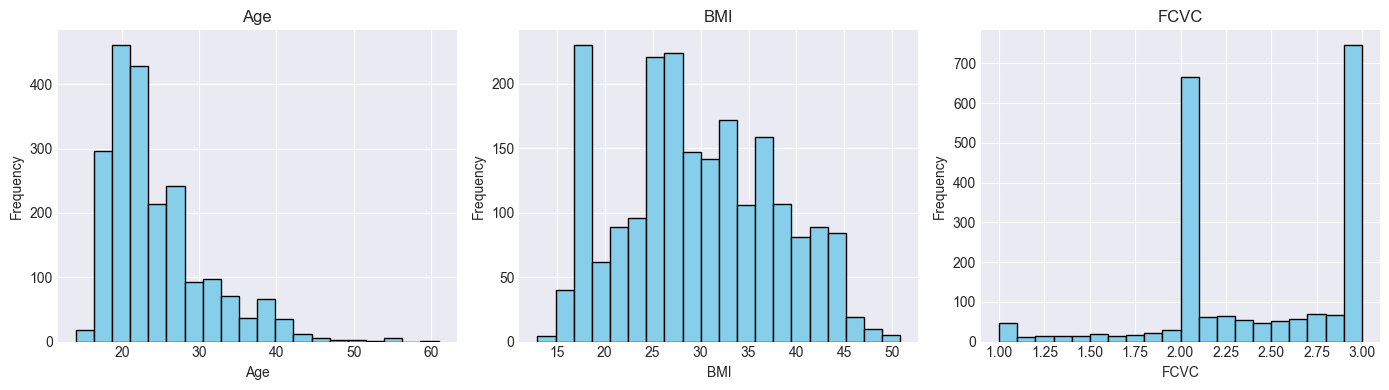

In [69]:
# Pilih beberapa variabel penting saja
important_vars = ['Age', 'BMI', 'FCVC']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, col in enumerate(important_vars):
    axes[idx].hist(df_clean[col], bins=20, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Boxplot untuk Outlier

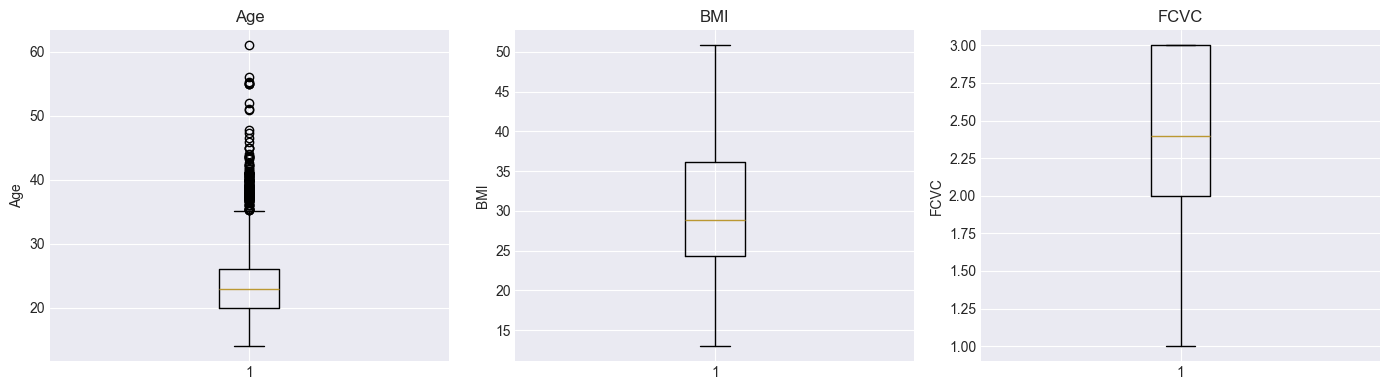

In [70]:
# Boxplot untuk variabel penting
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, col in enumerate(important_vars):
    axes[idx].boxplot(df_clean[col].dropna())
    axes[idx].set_title(f'{col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

### Visualisasi Data Kategorik

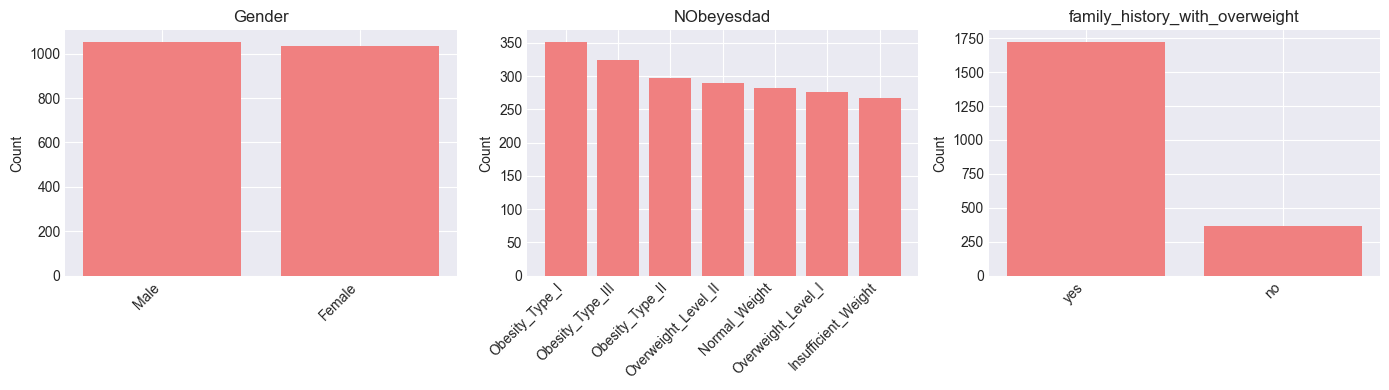

In [71]:
# Visualisasi beberapa variabel kategorik penting
important_cat = ['Gender', 'NObeyesdad', 'family_history_with_overweight']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, col in enumerate(important_cat):
    value_counts = df_clean[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, color='lightcoral')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Korelasi Antar Variabel

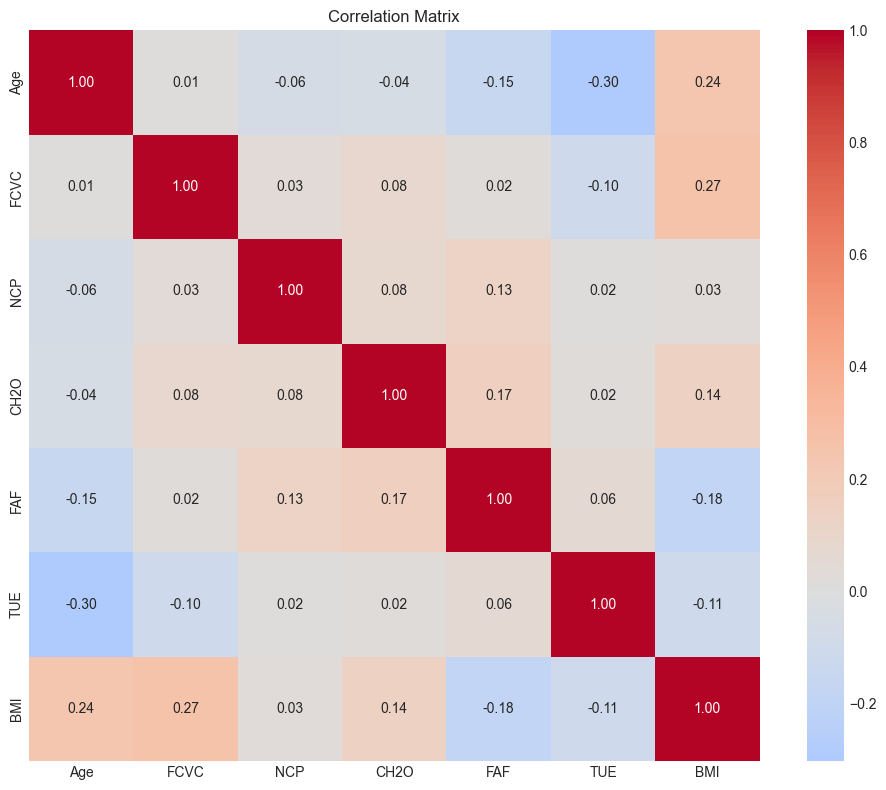

In [72]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

plt.figure(figsize=(10, 8))
correlation = df_clean[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Preprocessing Data

### Label Encoding

In [73]:
df_preprocessed = df_clean.copy()

categorical_cols = df_preprocessed.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_preprocessed[col] = le.fit_transform(df_preprocessed[col])
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)}")

Gender: ['Female', 'Male']
family_history_with_overweight: ['no', 'yes']
FAVC: ['no', 'yes']
CAEC: ['Always', 'Frequently', 'Sometimes', 'no']
SMOKE: ['no', 'yes']
SCC: ['no', 'yes']
CALC: ['Always', 'Frequently', 'Sometimes', 'no']
MTRANS: ['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']
NObeyesdad: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']


In [74]:
df_preprocessed.head()

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,BMI
0,0,21.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1,24.386526
1,0,21.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1,24.238227
2,1,23.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1,23.765432
3,1,27.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5,26.851852
4,1,22.0,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6,28.342381


### Feature Scaling

In [75]:
# Pisahkan features dan target
if 'NObeyesdad' in df_preprocessed.columns:
    X = df_preprocessed.drop('NObeyesdad', axis=1)
    y = df_preprocessed['NObeyesdad']
else:
    X = df_preprocessed.copy()
    y = None

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Gabung kembali dengan target
if y is not None:
    df_final = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)
else:
    df_final = X_scaled_df.copy()

print(f"Shape data final: {df_final.shape}")

Shape data final: (2111, 16)


In [76]:
df_final.head()

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI,NObeyesdad
0,-1.008179,-0.526613,0.460394,-2.754719,-0.788364,0.390906,0.318128,-0.146755,-0.007810,-0.219584,-1.186977,0.554211,1.411836,0.506768,-0.670475,1.0
1,-1.008179,-0.526613,0.460394,-2.754719,1.082164,0.390906,0.318128,6.814090,1.636552,4.554073,2.328908,-1.090505,-0.522834,0.506768,-0.688960,1.0
2,0.991887,-0.212507,0.460394,-2.754719,-0.788364,0.390906,0.318128,-0.146755,-0.007810,-0.219584,1.156947,0.554211,-2.457503,0.506768,-0.747890,1.0
3,0.991887,0.415705,-2.172052,-2.754719,1.082164,0.390906,0.318128,-0.146755,-0.007810,-0.219584,1.156947,-1.090505,-2.457503,1.297220,-0.363194,5.0
4,0.991887,-0.369560,-2.172052,-2.754719,-0.788364,-2.225418,0.318128,-0.146755,-0.007810,-0.219584,-1.186977,-1.090505,-0.522834,0.506768,-0.177412,6.0


## Simpan Data

In [109]:
# Simpan data yang sudah diproses
df_clean.to_csv('obesity_data_cleaned.csv', index=False)
df_preprocessed.to_csv('obesity_data_encoded.csv', index=False)
df_final.to_csv('obesity_data_preprocessed.csv', index=False)

print("Data berhasil disimpan:")
print("obesity_data_cleaned.csv")
print("obesity_data_encoded.csv")
print("obesity_data_preprocessed.csv")

Data berhasil disimpan:
obesity_data_cleaned.csv
obesity_data_encoded.csv
obesity_data_preprocessed.csv


## Import khusus PCA

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


## matriks fitur untuk PCA

In [79]:
target_col = "NObeyesdad"

if target_col in df_final.columns:
    X_pca_input = df_final.drop(columns=[target_col]).copy()
    y_target = df_final[target_col].copy()
else:
    X_pca_input = df_final.copy()
    y_target = None

print("Shape X_pca_input:", X_pca_input.shape)
X_pca_input.head()


Shape X_pca_input: (2111, 15)


,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI
0,-1.008179,-0.526613,0.460394,-2.754719,-0.788364,0.390906,0.318128,-0.146755,-0.007810,-0.219584,-1.186977,0.554211,1.411836,0.506768,-0.670475
1,-1.008179,-0.526613,0.460394,-2.754719,1.082164,0.390906,0.318128,6.814090,1.636552,4.554073,2.328908,-1.090505,-0.522834,0.506768,-0.688960
2,0.991887,-0.212507,0.460394,-2.754719,-0.788364,0.390906,0.318128,-0.146755,-0.007810,-0.219584,1.156947,0.554211,-2.457503,0.506768,-0.747890
3,0.991887,0.415705,-2.172052,-2.754719,1.082164,0.390906,0.318128,-0.146755,-0.007810,-0.219584,1.156947,-1.090505,-2.457503,1.297220,-0.363194
4,0.991887,-0.369560,-2.172052,-2.754719,-0.788364,-2.225418,0.318128,-0.146755,-0.007810,-0.219584,-1.186977,-1.090505,-0.522834,0.506768,-0.177412


## Cek jumlah NaN total + per kolom

In [80]:
# total NaN
print("Total NaN:", X_pca_input.isna().sum().sum())

# NaN per kolom (urut dari terbesar)
nan_per_col = X_pca_input.isna().sum().sort_values(ascending=False)
nan_per_col[nan_per_col > 0]


Total NaN: 360


Gender                            24
Age                               24
family_history_with_overweight    24
FAVC                              24
FCVC                              24
NCP                               24
CAEC                              24
SMOKE                             24
CH2O                              24
SCC                               24
FAF                               24
TUE                               24
CALC                              24
MTRANS                            24
BMI                               24
dtype: int64

## Sanity check

In [81]:
print("Missing values total:", X_pca_input.isna().sum().sum())
print("Duplicate rows in X:", X_pca_input.duplicated().sum())

non_numeric = X_pca_input.select_dtypes(exclude=["number"]).columns.tolist()
print("Non-numeric columns:", non_numeric)


Missing values total: 360
Duplicate rows in X: 23
Non-numeric columns: []


## baris mana yang NaN

In [82]:
rows_with_nan = X_pca_input[X_pca_input.isna().any(axis=1)]
print("Jumlah baris yang ada NaN:", rows_with_nan.shape[0])

rows_with_nan.head(10)


Jumlah baris yang ada NaN: 24


,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,BMI
98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
309,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
import numpy as np

print("INF count:", np.isinf(X_pca_input.to_numpy()).sum())

# Kalau ada INF, ubah jadi NaN agar bisa di-handle bersama
X_pca_input = X_pca_input.replace([np.inf, -np.inf], np.nan)

print("Total NaN setelah replace INF:", X_pca_input.isna().sum().sum())


INF count: 0
Total NaN setelah replace INF: 360
 0
Total NaN setelah replace INF: 360


## Deteksi baris yang full-NaN

In [84]:
mask_all_nan = X_pca_input.isna().all(axis=1)
print("Baris full-NaN:", mask_all_nan.sum())

idx_all_nan = X_pca_input.index[mask_all_nan]
idx_all_nan[:15], len(idx_all_nan)


Baris full-NaN: 24


(Index([98, 106, 174, 179, 184, 209, 309, 460, 467, 496, 527, 659, 663, 763,
        764],
       dtype='int64'),
 24)

## Drop 24 baris full-NaN

In [85]:
X_pca_fixed = X_pca_input.loc[~mask_all_nan].copy()

# kalau kamu punya y_target (mis. NObeyesdad) untuk interpretasi, ikut dibuang juga
if 'y_target' in globals() and y_target is not None:
    y_target_fixed = y_target.loc[~mask_all_nan].copy()
else:
    y_target_fixed = None

print("Sebelum:", X_pca_input.shape, "| Total NaN:", X_pca_input.isna().sum().sum())
print("Sesudah :", X_pca_fixed.shape, "| Total NaN:", X_pca_fixed.isna().sum().sum())


Sebelum: (2111, 15) | Total NaN: 360
Sesudah : (2087, 15) | Total NaN: 0


## Mengecek Nan

In [86]:
print("NaN X_pca_fixed :", X_pca_fixed.isna().sum().sum())


NaN X_pca_fixed : 0


## Fit PCA “full” untuk melihat pola explained variance

In [ ]:
from sklearn.decomposition import PCA
import numpy as np

pca_full = PCA(random_state=42)
pca_full.fit(X_pca_fixed)

explained_var = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

print("OK. Jumlah komponen:", len(explained_var))
print("Cum explained variance terakhir:", cum_explained[-1])


OK. Jumlah komponen: 15
Cum explained variance terakhir: 1.0


## Fit PCA full + tentukan n_components (80/90/95%) + plot

Komponen untuk 80%: 10
Komponen untuk 90%: 12
Komponen untuk 95%: 13


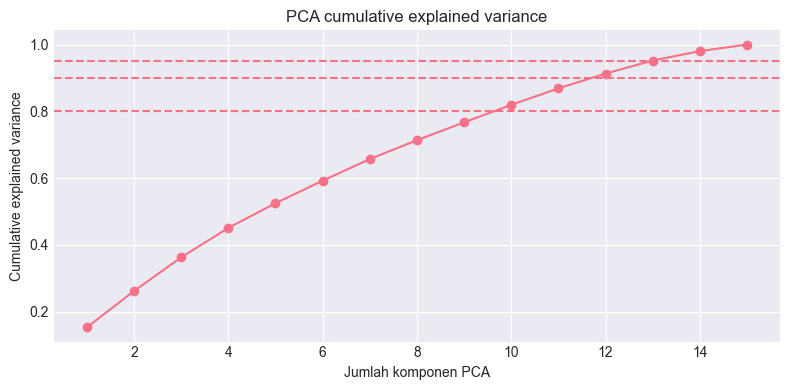

In [88]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca_full = PCA(random_state=42)
pca_full.fit(X_pca_fixed)

explained_var = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained_var)

n80 = int(np.argmax(cum_explained >= 0.80) + 1)
n90 = int(np.argmax(cum_explained >= 0.90) + 1)
n95 = int(np.argmax(cum_explained >= 0.95) + 1)

print("Komponen untuk 80%:", n80)
print("Komponen untuk 90%:", n90)
print("Komponen untuk 95%:", n95)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker="o")
plt.axhline(0.80, linestyle="--")
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Jumlah komponen PCA")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.tight_layout()
plt.show()


## Fit PCA final (n90 sebagai default) + transform



In [89]:
n_components = n90

pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_pca_fixed)

pc_cols = [f"PC{i}" for i in range(1, n_components+1)]
df_pca = pd.DataFrame(X_pca, columns=pc_cols)

print("df_pca shape:", df_pca.shape)
df_pca.head()


df_pca shape: (2087, 12)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-1.320051,-0.019426,-0.341932,-0.624815,1.091139,-0.313949,0.807622,-1.281238,2.145810,1.301648,1.444812,0.042342
1,-2.276778,-0.377643,-1.493320,5.611742,-1.927553,-5.655206,2.195309,0.135148,1.521266,-1.197159,-0.327403,1.507049
2,-1.011026,0.013645,1.148828,1.375444,-0.946955,-0.644950,-1.284555,-1.448886,0.460741,0.617506,1.321896,-2.275643
3,-1.469874,-0.306706,-0.742431,2.374835,-0.656734,-0.248427,-2.055850,-2.423407,-0.805070,-0.506820,1.082236,-1.600797
4,-1.451972,-1.171971,-0.823651,-0.725793,0.550922,-1.934597,-1.976201,-2.347615,-0.318705,0.964133,0.520284,-0.777675


## Ringkasan explained variance per PC

In [90]:
pca_summary = pd.DataFrame({
    "PC": pc_cols,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_)
})

pca_summary


,PC,explained_variance_ratio,cumulative
0,PC1,0.152891,0.152891
1,PC2,0.109019,0.261910
2,PC3,0.100658,0.362568
3,PC4,0.088379,0.450948
4,PC5,0.073760,0.524708
5,PC6,0.067514,0.592222
6,PC7,0.064829,0.657050
7,PC8,0.056607,0.713657
8,PC9,0.053314,0.766972
9,PC10,0.052451,0.819422


## Plot scree (variance per PC) + cumulative versi “final PCA”

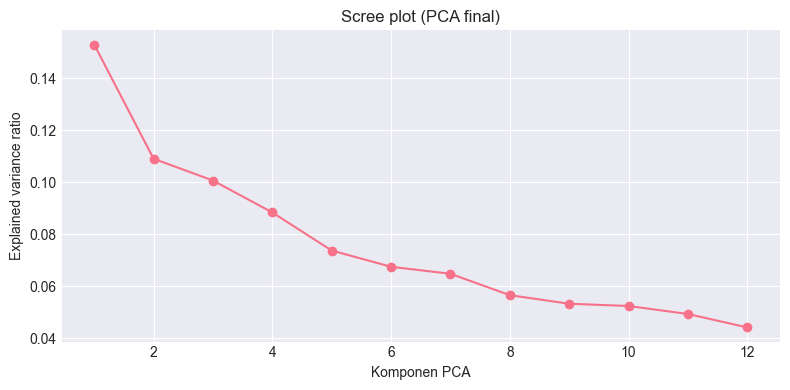

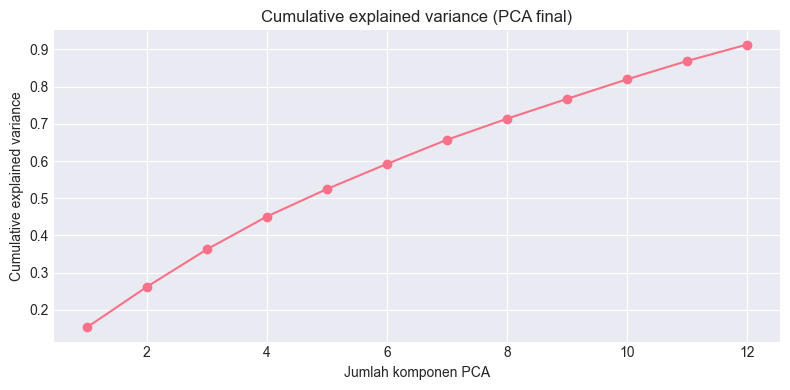

In [91]:
# Scree plot
plt.figure(figsize=(8,4))
plt.plot(range(1, n_components+1), pca.explained_variance_ratio_, marker="o")
plt.xlabel("Komponen PCA")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot (PCA final)")
plt.tight_layout()
plt.show()

# Cumulative (final PCA)
plt.figure(figsize=(8,4))
plt.plot(range(1, n_components+1), np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Jumlah komponen PCA")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance (PCA final)")
plt.tight_layout()
plt.show()


## Loadings (kontribusi fitur ke tiap PC)

In [92]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_pca_fixed.columns,
    columns=pc_cols
)

loadings.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Gender,0.076280,-0.148279,0.591854,0.081312,-0.095679,-0.125592,-0.087243,-0.173069,-0.044931,-0.028708,-0.365156,-0.336156
Age,0.410021,-0.472929,-0.111160,0.085433,0.008742,-0.019392,0.063821,0.118378,-0.034829,0.102107,0.142470,-0.059539
family_history_with_overweight,0.426218,0.196526,0.154337,0.018112,0.103340,-0.075700,0.343988,0.030257,0.233417,0.217626,-0.231231,-0.250241
FAVC,0.286373,0.173375,0.132106,-0.284633,-0.204036,0.206488,-0.047051,0.455234,-0.316918,-0.282609,-0.391494,0.393798
FCVC,0.077825,0.230254,-0.454945,0.363255,0.134269,0.130569,0.250312,0.106547,-0.298954,-0.199476,0.034714,-0.190276


## Top fitur pembentuk PC1–PC3

In [93]:
def top_loadings(loadings_df, pc_name, top_n=12):
    s = loadings_df[pc_name].copy()
    return s.reindex(s.abs().sort_values(ascending=False).index).head(top_n)

for pc in pc_cols[:3]:
    print(f"\n=== Top loadings untuk {pc} ===")
    display(top_loadings(loadings, pc, top_n=12))



=== Top loadings untuk PC1 ===


BMI                               0.479402
family_history_with_overweight    0.426218
Age                               0.410021
CAEC                              0.309072
FAVC                              0.286373
MTRANS                           -0.275604
SCC                              -0.257085
TUE                              -0.178402
FAF                              -0.175409
CALC                             -0.123000
CH2O                              0.105654
FCVC                              0.077825
Name: PC1, dtype: float64


=== Top loadings untuk PC2 ===


MTRANS                            0.553844
Age                              -0.472929
BMI                               0.316596
TUE                               0.301684
CH2O                              0.271861
FCVC                              0.230254
family_history_with_overweight    0.196526
FAVC                              0.173375
CAEC                              0.166630
Gender                           -0.148279
CALC                             -0.120203
SMOKE                            -0.101163
Name: PC2, dtype: float64


=== Top loadings untuk PC3 ===


Gender                            0.591854
FCVC                             -0.454945
FAF                               0.365639
TUE                               0.270580
CH2O                              0.209861
SCC                              -0.204540
NCP                               0.174888
family_history_with_overweight    0.154337
BMI                              -0.153415
CALC                              0.136193
FAVC                              0.132106
CAEC                              0.128799
Name: PC3, dtype: float64

## Visualisasi PCA 2D (PC1 vs PC2)

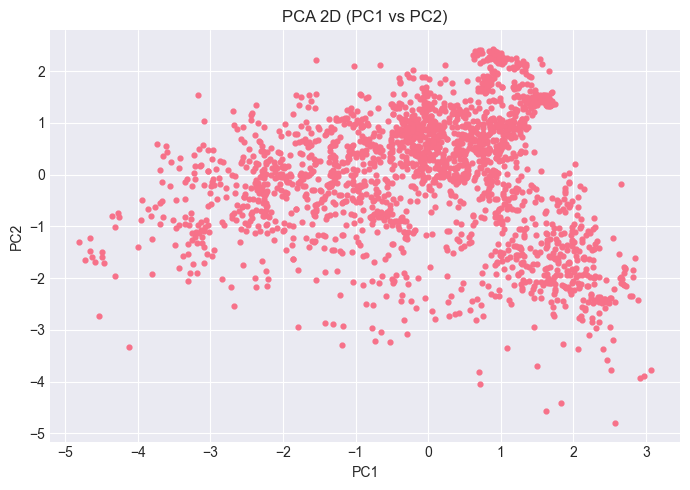

In [94]:
plt.figure(figsize=(7,5))
plt.scatter(df_pca["PC1"], df_pca["PC2"], s=12)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D (PC1 vs PC2)")
plt.tight_layout()
plt.show()


## original vs reduced

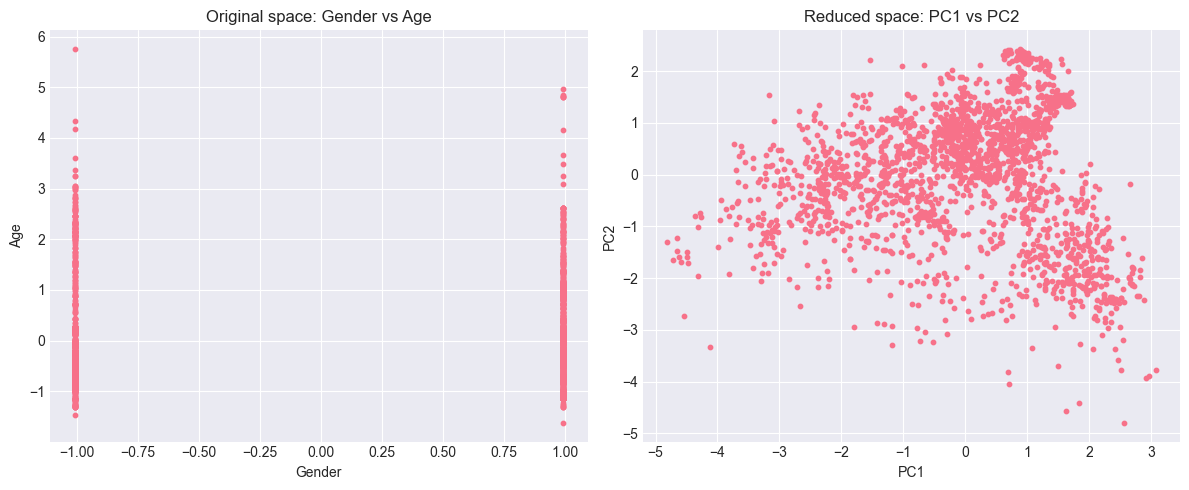

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

if "Height" in X_pca_fixed.columns and "Weight" in X_pca_fixed.columns:
    xcol, ycol = "Height", "Weight"
else:
    xcol, ycol = X_pca_fixed.columns[:2]

plt.scatter(X_pca_fixed[xcol], X_pca_fixed[ycol], s=10)
plt.xlabel(xcol)
plt.ylabel(ycol)
plt.title(f"Original space: {xcol} vs {ycol}")

plt.subplot(1,2,2)
plt.scatter(df_pca["PC1"], df_pca["PC2"], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Reduced space: PC1 vs PC2")

plt.tight_layout()
plt.show()


## Biplot (PC1 vs PC2)

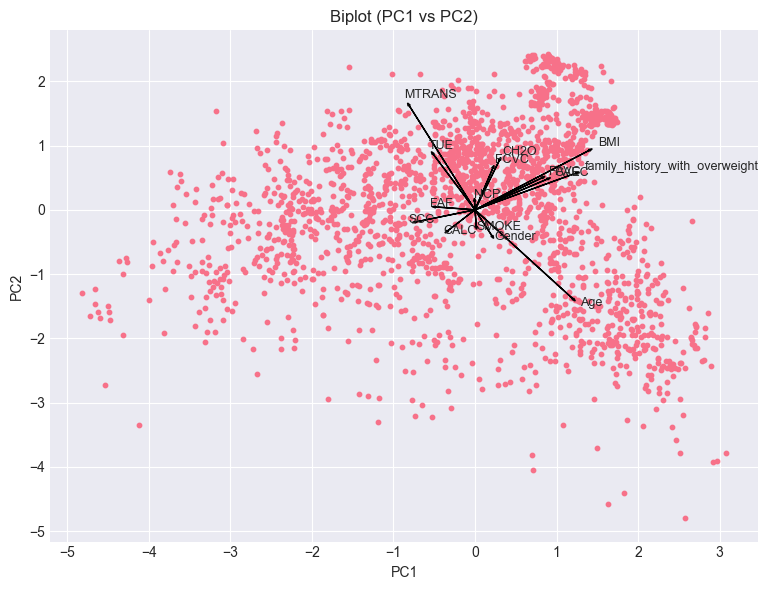

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# pastikan ada minimal PC1 dan PC2
pc1 = df_pca["PC1"].values
pc2 = df_pca["PC2"].values

plt.figure(figsize=(8,6))
plt.scatter(pc1, pc2, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot (PC1 vs PC2)")

# gambar vektor fitur (pakai loadings PC1/PC2)
# skala panah supaya keliatan (bisa kamu adjust)
scale = 3

for feature in loadings.index:
    x = loadings.loc[feature, "PC1"]
    y = loadings.loc[feature, "PC2"]
    plt.arrow(0, 0, x*scale, y*scale, head_width=0.03, length_includes_head=True)
    plt.text(x*scale*1.05, y*scale*1.05, feature, fontsize=9)

plt.tight_layout()
plt.show()


## 3D plot jika menggunakan 3 PC

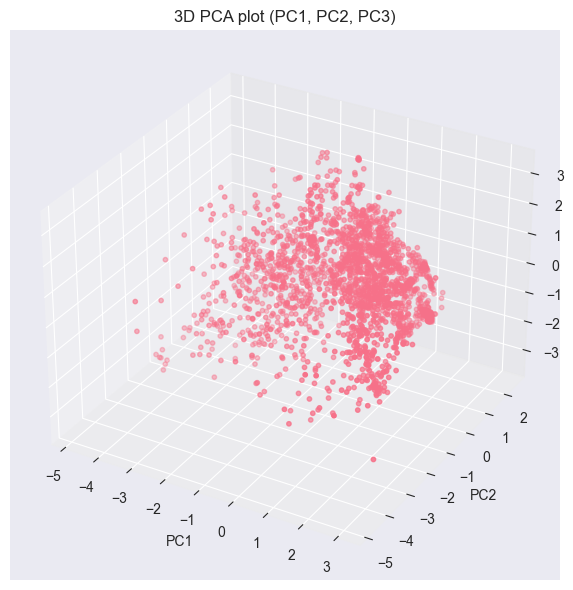

In [97]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

if {"PC1","PC2","PC3"}.issubset(df_pca.columns):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(df_pca["PC1"], df_pca["PC2"], df_pca["PC3"], s=10)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("3D PCA plot (PC1, PC2, PC3)")
    plt.tight_layout()
    plt.show()
else:
    print("PC3 tidak tersedia (n_components < 3).")


## PCA 2D

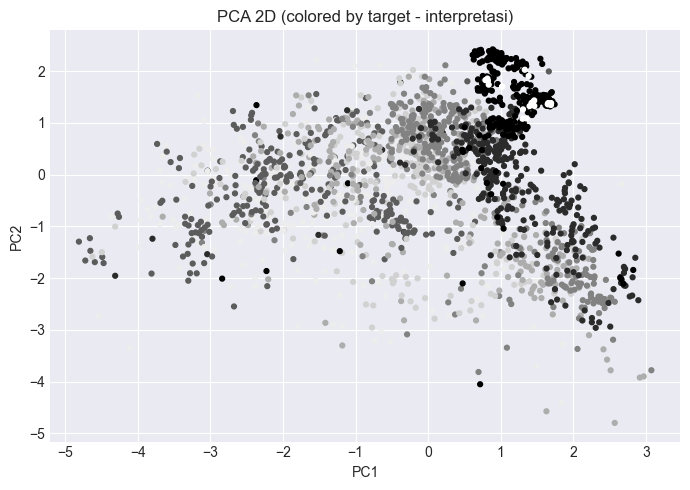

In [98]:
if 'y_target_fixed' in globals() and y_target_fixed is not None:
    y_codes = pd.factorize(y_target_fixed)[0]

    plt.figure(figsize=(7,5))
    plt.scatter(df_pca["PC1"], df_pca["PC2"], c=y_codes, s=12)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA 2D (colored by target - interpretasi)")
    plt.tight_layout()
    plt.show()
else:
    print("y_target_fixed tidak tersedia, skip plot berwarna.")


## Korelasi PC dengan fitur asli

In [99]:
# Gabungkan PC dengan fitur asli untuk korelasi (hanya kalau semua numerik)
df_join = pd.concat([X_pca_fixed.reset_index(drop=True), df_pca], axis=1)

corr_with_pc1 = df_join.corr(numeric_only=True)["PC1"].sort_values(key=lambda s: s.abs(), ascending=False)
corr_with_pc2 = df_join.corr(numeric_only=True)["PC2"].sort_values(key=lambda s: s.abs(), ascending=False)

print("Korelasi terbesar (abs) dengan PC1:")
display(corr_with_pc1.head(15))

print("\nKorelasi terbesar (abs) dengan PC2:")
display(corr_with_pc2.head(15))


Korelasi terbesar (abs) dengan PC1:


PC1                               1.000000
BMI                               0.725999
family_history_with_overweight    0.645457
Age                               0.620930
CAEC                              0.468054
FAVC                              0.433678
MTRANS                           -0.417371
SCC                              -0.389326
TUE                              -0.270169
FAF                              -0.265637
CALC                             -0.186269
CH2O                              0.160000
FCVC                              0.117857
Gender                            0.115517
SMOKE                             0.009877
Name: PC1, dtype: float64


Korelasi terbesar (abs) dengan PC2:


PC2                               1.000000
MTRANS                            0.708247
Age                              -0.604774
BMI                               0.404858
TUE                               0.385789
CH2O                              0.347651
FCVC                              0.294446
family_history_with_overweight    0.251314
FAVC                              0.221710
CAEC                              0.213084
Gender                           -0.189616
CALC                             -0.153713
SMOKE                            -0.129366
SCC                              -0.085368
NCP                               0.076653
Name: PC2, dtype: float64

## Menyimpan output PCA

In [100]:
df_pca.to_csv("pca_features.csv", index=False)
pca_summary.to_csv("pca_summary.csv", index=False)
loadings.to_csv("pca_loadings.csv")

print("Saved files:")
print("- pca_features.csv")
print("- pca_summary.csv")
print("- pca_loadings.csv")


Saved files:
- pca_features.csv
- pca_summary.csv
- pca_loadings.csv


## K-MEANS CLUSTERING & EVALUATION

In [101]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_samples

In [102]:
pca_data = pd.read_csv("pca_features.csv")
print("dimensi data PCA:", pca_data.shape)
pca_data.head()

dimensi data PCA: (2087, 12)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-1.320051,-0.019426,-0.341932,-0.624815,1.091139,-0.313949,0.807622,-1.281238,2.145810,1.301648,1.444812,0.042342
1,-2.276778,-0.377643,-1.493320,5.611742,-1.927553,-5.655206,2.195309,0.135148,1.521266,-1.197159,-0.327403,1.507049
2,-1.011026,0.013645,1.148828,1.375444,-0.946955,-0.644950,-1.284555,-1.448886,0.460741,0.617506,1.321896,-2.275643
3,-1.469874,-0.306706,-0.742431,2.374835,-0.656734,-0.248427,-2.055850,-2.423407,-0.805070,-0.506820,1.082236,-1.600797
4,-1.451972,-1.171971,-0.823651,-0.725793,0.550922,-1.934597,-1.976201,-2.347615,-0.318705,0.964133,0.520284,-0.777675


menentukan Jumlah Cluster Optimal (Elbow & Silhouette)

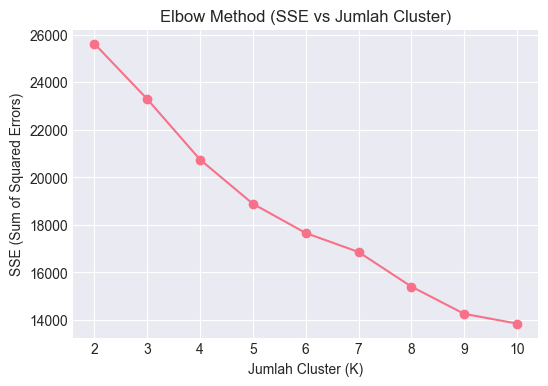

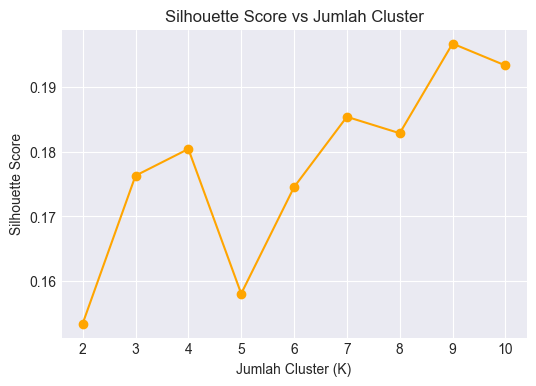

In [103]:
sse = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(pca_data, kmeans.labels_))

# Elbow Method Plot
plt.figure(figsize=(6,4))
plt.plot(K_range, sse, marker='o')
plt.title('Elbow Method (SSE vs Jumlah Cluster)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.grid(True)
plt.show()

# Silhouette Score Plot
plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs Jumlah Cluster')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

Menentukan K Optimal Secara Objektif

In [104]:
# dari Silhouette, ambil nilai K dengan skor tertinggi
best_k_sil = K_range[np.argmax(silhouette_scores)]

# dari Elbow (manual lihat plot) — kalau kamu mau otomatis, bisa pakai perbedaan turunan
diff_sse = np.diff(sse)
diff_rate = np.abs(diff_sse[1:] / diff_sse[:-1])
elbow_k = np.argmin(diff_rate) + 3  # perkiraan posisi elbow

print(f"Perkiraan K (Elbow Method): {elbow_k}")
print(f"Perkiraan K (Silhouette Score): {best_k_sil}")

# Pilih salah satu, misal pakai Silhouette karena lebih objektif:
K_optimal = best_k_sil
print(f"K Optimal dipilih berdasarkan Silhouette Score = {K_optimal}")

Perkiraan K (Elbow Method): 9
Perkiraan K (Silhouette Score): 9
K Optimal dipilih berdasarkan Silhouette Score = 9


Implementasi K-Means

In [105]:
kmeans = KMeans(n_clusters=K_optimal, random_state=42)
clusters = kmeans.fit_predict(pca_data)
pca_data['Cluster'] = clusters

Evaluasi Clustering

In [106]:
sil_score = silhouette_score(pca_data.iloc[:, :-1], clusters)
db_index = davies_bouldin_score(pca_data.iloc[:, :-1], clusters)
ch_score = calinski_harabasz_score(pca_data.iloc[:, :-1], clusters)

print("Evaluasi Clustering:")
print(f"Silhouette Score       : {sil_score:.4f}")
print(f"Davies-Bouldin Index   : {db_index:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Evaluasi Clustering:
Silhouette Score       : 0.1967
Davies-Bouldin Index   : 1.6456
Calinski-Harabasz Score: 261.3639


Visualisasi Hasil Clustering

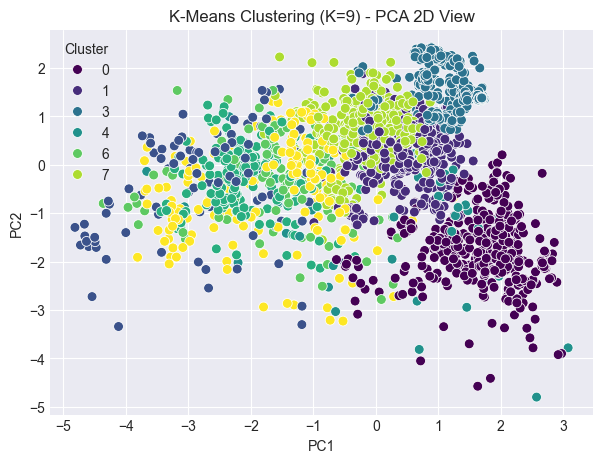

In [107]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=pca_data, x=pca_data.columns[0], y=pca_data.columns[1],
                hue='Cluster', palette='viridis', s=50)
plt.title(f'K-Means Clustering (K={K_optimal}) - PCA 2D View')
plt.show()


Distribusi Tiap Cluster

Jumlah anggota tiap cluster:
Cluster
0    359
1    451
2     91
3    349
4     44
5    178
6    133
7    309
8    173
Name: count, dtype: int64


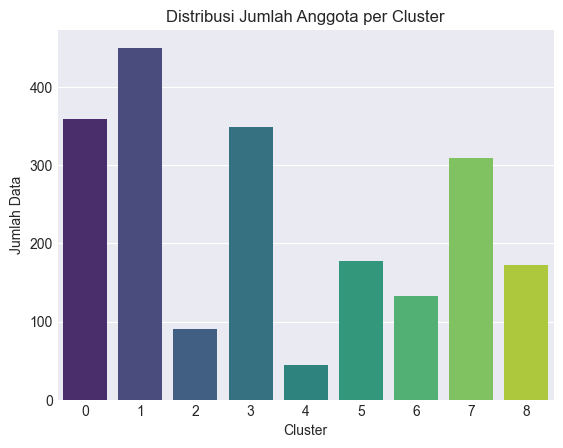

File hasil clustering disimpan sebagai: pca_clustered.csv


In [108]:
cluster_counts = pca_data['Cluster'].value_counts().sort_index()
print("Jumlah anggota tiap cluster:")
print(cluster_counts)

sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Distribusi Jumlah Anggota per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.show()


pca_data.to_csv("pca_clustered.csv", index=False)
print("File hasil clustering disimpan sebagai: pca_clustered.csv")

Berdasarkan hasil clustering ini, dapat diinterpretasikan bahwa:

- Data obesitas terbagi menjadi 7 kelompok utama berdasarkan kombinasi faktor gaya hidup, kebiasaan makan, dan aktivitas fisik yang terekstraksi lewat PCA.

- Tiap cluster merepresentasikan pola perilaku berbeda:

  - Ada kelompok dengan pola hidup sehat dan aktif (cenderung memiliki risiko obesitas rendah),

  - Ada pula kelompok dengan konsumsi tinggi, aktivitas rendah, atau kebiasaan makan tidak teratur (cenderung berisiko tinggi obesitas).

- Cluster 3, yang berisi individu terbanyak, kemungkinan besar mencerminkan pola paling umum di dataset — misalnya kelompok dengan gaya hidup moderat (aktivitas sedang dan pola makan relatif seimbang).

- Cluster lain yang berukuran lebih kecil bisa mencerminkan pola ekstrem, seperti:

  - Aktivitas sangat rendah + konsumsi tinggi (obesitas tinggi),

  - Aktivitas tinggi + konsumsi rendah (berat badan ideal).